# 03 · Studi Komparatif (Setelah Fine-tuning)

**Alur:** data → hasil model fine-tuning → evaluasi → figur.

Menggabungkan metrik multi-seed dari **02a/02b/02c** (dan baseline vanilla dari **01**)
menjadi tabel perbandingan rata-rata ± std + figur publikasi.

Dua pengujian inti studi ini:
1. **Baseline vanilla:** YOLOv8s vs YOLO11s (zero-shot COCO) — dari notebook 01.
2. **Fine-tuning:** YOLOv8s vs YOLO11s vs YOLOv8s+CBAM — dari notebook 02a/b/c.

In [1]:
# === Setup: lingkungan, seed, util (pure-notebook: self-contained, tanpa src/) ===
from __future__ import annotations
import os, gc, json, random, sys, platform
from pathlib import Path

import numpy as np
import torch
import yaml

# Lokasi repo: telusuri ke atas dari cwd sampai menemukan requirements.txt
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "requirements.txt").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

DATA_YAML = REPO_ROOT / "data" / "helmet-roboflow" / "data.yaml"
TEST_IMG_DIR = REPO_ROOT / "data" / "helmet-roboflow" / "test" / "images"
TEST_LBL_DIR = REPO_ROOT / "data" / "helmet-roboflow" / "test" / "labels"
EXP = REPO_ROOT / "experiments"
FIG = REPO_ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
CLASS_NAMES = ["helmet", "license_plate", "motorcyclist"]


def set_seed(seed: int = 42, deterministic: bool = True) -> int:
    """Patok seed untuk random/numpy/torch (reproducibility)."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    return seed


def clear_gpu() -> None:
    """Bersihkan cache GPU antar-run agar tak ada memori sisa (hindari redundant)."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


def collect_env() -> dict:
    info = {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "torch": torch.__version__,
        "cuda": torch.version.cuda,
        "cuda_available": torch.cuda.is_available(),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    }
    try:
        import ultralytics
        info["ultralytics"] = ultralytics.__version__
    except ImportError:
        info["ultralytics"] = None
    return info


def save_metrics(metrics: dict, run_dir: Path) -> dict:
    """Tulis metrik ke metrics.json + metrics.csv di folder run (satu sumber kebenaran)."""
    import pandas as pd
    run_dir = Path(run_dir)
    run_dir.mkdir(parents=True, exist_ok=True)
    (run_dir / "metrics.json").write_text(json.dumps(metrics, indent=2))
    pd.DataFrame([metrics]).to_csv(run_dir / "metrics.csv", index=False)
    return metrics


print("REPO_ROOT :", REPO_ROOT)
print("ENV       :", json.dumps(collect_env(), indent=2))
assert DATA_YAML.exists(), f"data.yaml tidak ditemukan: {DATA_YAML}"


REPO_ROOT : /home/bdo/code/jupyter-code/foldersr/work/project-cv
ENV       : {
  "python": "3.12.13",
  "platform": "Linux-6.8.0-124-generic-x86_64-with-glibc2.35",
  "torch": "2.8.0+cu128",
  "cuda": "12.8",
  "cuda_available": true,
  "gpu": "NVIDIA GeForce RTX 4090",
  "ultralytics": "8.4.65"
}


## Agregasi metrik (rata-rata ± std)

In [2]:
# === Registry run (namespace studi baru; bukan run lama ms_*/helm_*) ===
import statistics as stats
import pandas as pd

RUNS = {
    "YOLOv8s (vanilla)":         ["vanilla_yolov8s"],
    "YOLO11s (vanilla)":         ["vanilla_yolo11s"],
    "YOLOv8s (fine-tuned)":      ["ft_yolov8s_seed42", "ft_yolov8s_seed0", "ft_yolov8s_seed1"],
    "YOLO11s (fine-tuned)":      ["ft_yolo11s_seed42", "ft_yolo11s_seed0", "ft_yolo11s_seed1"],
    "YOLOv8s+CBAM (fine-tuned)": ["ft_cbam_seed42", "ft_cbam_seed0", "ft_cbam_seed1"],
}


def load_runs():
    rows = []
    for model, runs in RUNS.items():
        m50, m5095, fps = [], [], []
        for r in runs:
            p = EXP / r / "metrics.json"
            if p.exists():
                d = json.loads(p.read_text())
                m50.append(d.get("mAP50"))
                m5095.append(d.get("mAP50_95"))
                if d.get("fps"):
                    fps.append(d["fps"])
        m50 = [v for v in m50 if v is not None]
        rows.append({
            "Model": model,
            "n_seed": len(m50),
            "mAP@0.5": stats.mean(m50) if m50 else float("nan"),
            "mAP@0.5_std": stats.stdev(m50) if len(m50) > 1 else 0.0,
            "mAP@[.5:.95]": stats.mean(m5095) if m5095 else float("nan"),
            "FPS": round(stats.mean(fps), 1) if fps else None,
        })
    return pd.DataFrame(rows)


summary = load_runs()
display(summary.style.format({
    "mAP@0.5": "{:.4f}", "mAP@0.5_std": "{:.4f}", "mAP@[.5:.95]": "{:.4f}"}, na_rep="—"))

,Model,n_seed,mAP@0.5,mAP@0.5_std,mAP@[.5:.95],FPS
0,YOLOv8s (vanilla),1,0.0986,0.0000,0.0270,—
1,YOLO11s (vanilla),1,0.1143,0.0000,0.0320,—
2,YOLOv8s (fine-tuned),3,0.9596,0.0008,0.6885,297.800000
3,YOLO11s (fine-tuned),3,0.9574,0.0019,0.6902,256.000000
4,YOLOv8s+CBAM (fine-tuned),3,0.9481,0.0006,0.6832,316.700000


## Figur

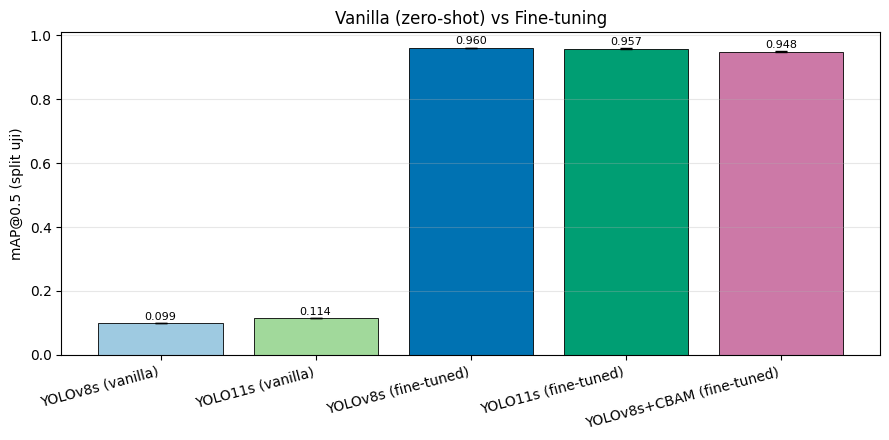

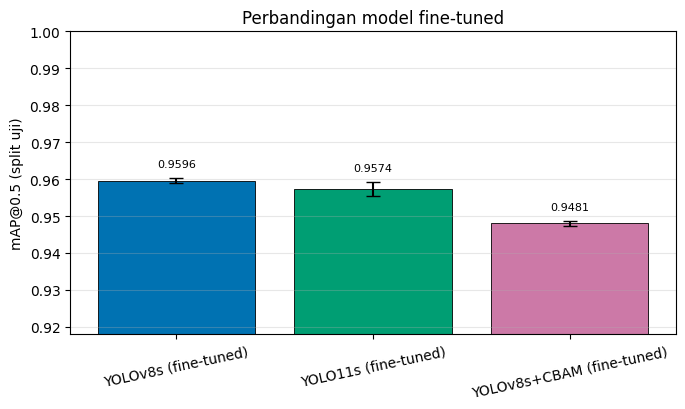

Figur tersimpan di /home/bdo/code/jupyter-code/foldersr/work/project-cv/results/figures


In [3]:
# === Figur perbandingan ===
%matplotlib inline
import matplotlib.pyplot as plt

COL = {
    "YOLOv8s (vanilla)": "#9ecae1", "YOLO11s (vanilla)": "#a1d99b",
    "YOLOv8s (fine-tuned)": "#0072B2", "YOLO11s (fine-tuned)": "#009E73",
    "YOLOv8s+CBAM (fine-tuned)": "#CC79A7",
}

# Fig 1: vanilla vs fine-tuned (headline studi)
fig, ax = plt.subplots(figsize=(9, 4.5))
d = summary.dropna(subset=["mAP@0.5"])
ax.bar(d["Model"], d["mAP@0.5"], yerr=d["mAP@0.5_std"], capsize=4,
       color=[COL.get(m, "#888") for m in d["Model"]], edgecolor="black", linewidth=0.6)
ax.set_ylabel("mAP@0.5 (split uji)")
ax.set_title("Vanilla (zero-shot) vs Fine-tuning")
for i, (v, e) in enumerate(zip(d["mAP@0.5"], d["mAP@0.5_std"])):
    ax.text(i, v + e + 0.01, f"{v:.3f}", ha="center", fontsize=8)
plt.xticks(rotation=15, ha="right"); ax.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig(FIG / "compare_vanilla_vs_finetuned.png", dpi=300); plt.show()

# Fig 2: hanya model fine-tuned (v8 vs v11 vs cbam)
ft = summary[summary["Model"].str.contains("fine-tuned")].dropna(subset=["mAP@0.5"])
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(ft["Model"], ft["mAP@0.5"], yerr=ft["mAP@0.5_std"], capsize=5,
       color=[COL.get(m, "#888") for m in ft["Model"]], edgecolor="black", linewidth=0.6)
lo = max(0.0, ft["mAP@0.5"].min() - 0.03)
ax.set_ylim(lo, 1.0); ax.set_ylabel("mAP@0.5 (split uji)")
ax.set_title("Perbandingan model fine-tuned")
for i, (v, e) in enumerate(zip(ft["mAP@0.5"], ft["mAP@0.5_std"])):
    ax.text(i, v + e + 0.003, f"{v:.4f}", ha="center", fontsize=8)
plt.xticks(rotation=12); ax.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig(FIG / "compare_finetuned.png", dpi=300); plt.show()
print("Figur tersimpan di", FIG)

## Kesimpulan (isi setelah seluruh notebook dijalankan)

- **Lonjakan vanilla → fine-tuned** mengukur manfaat transfer learning pada domain helm.
- **Antar model fine-tuned:** apakah YOLO11s (atensi C2PSA) atau CBAM mengalahkan
  YOLOv8s CNN-murni? Lihat selisih mAP@0.5 ± std.
- Sumber angka: `experiments/{vanilla_*, ft_*}/metrics.json`.